In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/sessions_14days.csv')

Mounted at /content/drive


ГИПОТЕЗА 6: КОНВЕРСИЯ ПО КАТЕГОРИЯМ ТОВАРОВ

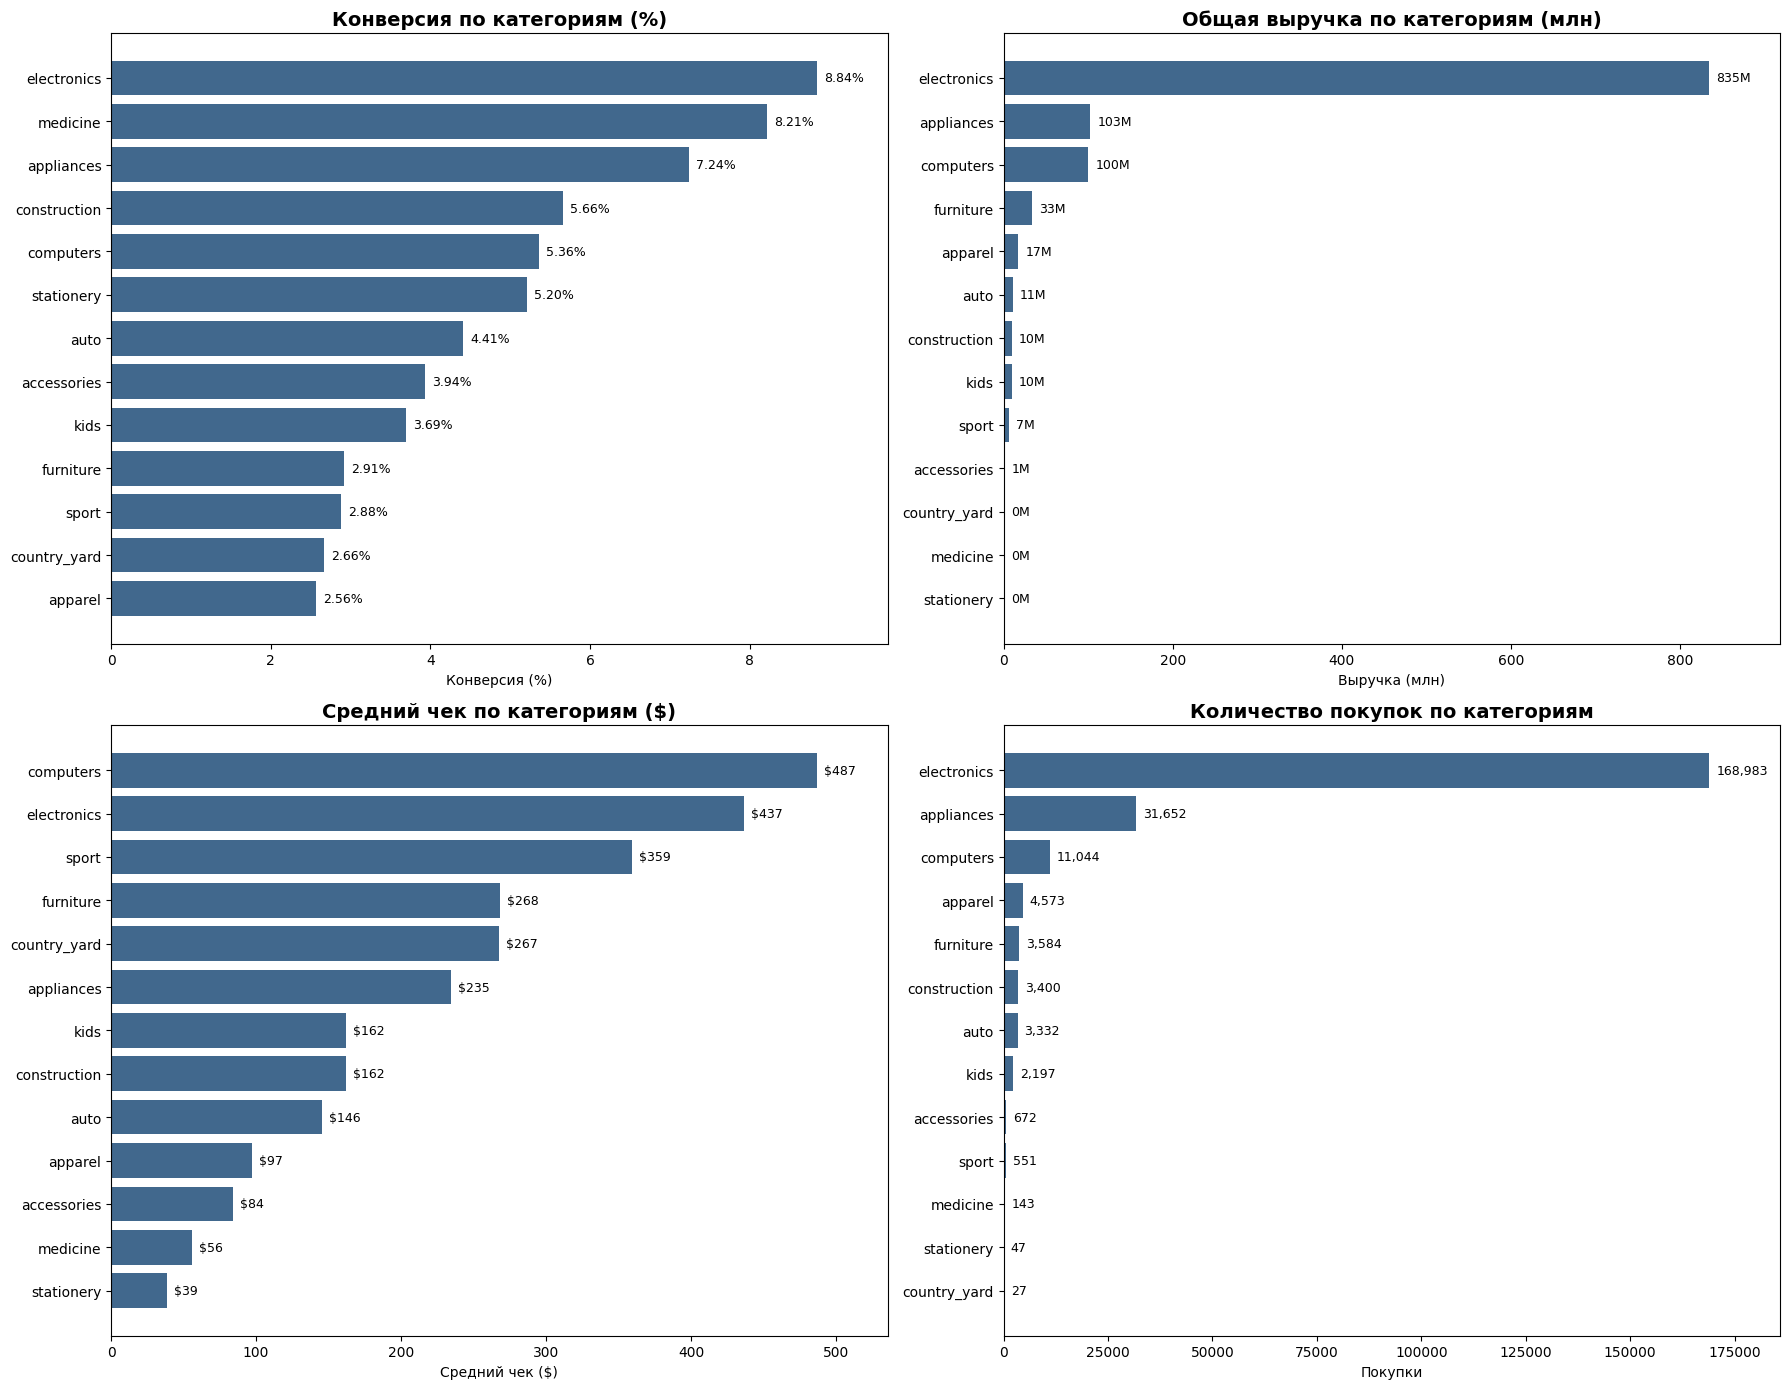

In [24]:
# Агрегация по категориям из данных
cat_data = df.groupby('main_category_viewed').agg(
    sessions=('made_purchase', 'count'),
    purchases=('made_purchase', 'sum'),
    conversion=('made_purchase', 'mean'),
    total_revenue=('avg_price', 'sum'),
    avg_check=('avg_price', 'mean')
).reset_index()

cat_data['conversion'] = cat_data['conversion'] * 100

# Сортировка
cat_conv = cat_data.sort_values('conversion', ascending=True)
cat_rev = cat_data.sort_values('total_revenue', ascending=True)
cat_check = cat_data[cat_data['avg_check'] > 0].sort_values('avg_check', ascending=True)
cat_purchases = cat_data.sort_values('purchases', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Конверсия
max_conv = cat_conv['conversion'].max()
axes[0, 0].barh(cat_conv['main_category_viewed'], cat_conv['conversion'], color='#1f4e79', alpha=0.85)
axes[0, 0].set_title('Конверсия по категориям (%)', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Конверсия (%)')
axes[0, 0].set_xlim(0, max_conv * 1.1)
for i, v in enumerate(cat_conv['conversion']):
    axes[0, 0].text(v + (max_conv * 0.01), i, f'{v:.2f}%', va='center', fontsize=9)

# Общая выручка
max_rev = cat_rev['total_revenue'].max() / 1e6
axes[0, 1].barh(cat_rev['main_category_viewed'], cat_rev['total_revenue'] / 1e6, color='#1f4e79', alpha=0.85)
axes[0, 1].set_title('Общая выручка по категориям (млн)', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Выручка (млн)')
axes[0, 1].set_xlim(0, max_rev * 1.1)
for i, v in enumerate(cat_rev['total_revenue'] / 1e6):
    axes[0, 1].text(v + (max_rev * 0.01), i, f'{v:.0f}M', va='center', fontsize=9)

# Средний чек
max_check = cat_check['avg_check'].max()
axes[1, 0].barh(cat_check['main_category_viewed'], cat_check['avg_check'], color='#1f4e79', alpha=0.85)
axes[1, 0].set_title('Средний чек по категориям ($)', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Средний чек ($)')
axes[1, 0].set_xlim(0, max_check * 1.1)
for i, v in enumerate(cat_check['avg_check']):
    axes[1, 0].text(v + (max_check * 0.01), i, f'${v:.0f}', va='center', fontsize=9)

# Количество покупок
max_purch = cat_purchases['purchases'].max()
axes[1, 1].barh(cat_purchases['main_category_viewed'], cat_purchases['purchases'], color='#1f4e79', alpha=0.85)
axes[1, 1].set_title('Количество покупок по категориям', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Покупки')
axes[1, 1].set_xlim(0, max_purch * 1.1)
for i, v in enumerate(cat_purchases['purchases']):
    axes[1, 1].text(v + (max_purch * 0.01), i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('category_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Детальнее рассмотрим категории с низкой выручкой.

In [31]:
for cat in ['medicine', 'stationery', 'country_yard']:
    cat_data = df[df['main_category_viewed'] == cat]
    cat_purchases = cat_data[cat_data['made_purchase'] == 1]


    print(f"\n{cat.upper()}")
    print(f"Всего сессий: {cat_data['user_session'].nunique()}")
    print(f"Уникальных пользователей: {cat_data['user_id'].nunique()}")
    print(f"Покупок: {cat_purchases.shape[0]}")
    print(f"Уникальных покупателей: {cat_purchases['user_id'].nunique()}")

    # Цены
    if cat_purchases.shape[0] > 0:
        print(f"  avg_price: мин={cat_purchases['avg_price'].min():.2f}, "
              f"макс={cat_purchases['avg_price'].max():.2f}, "
              f"сред={cat_purchases['avg_price'].mean():.2f}")

    else:
        print(f"\n ПОКУПОК НЕТ ВООБЩЕ!")



MEDICINE
Всего сессий: 1741
Уникальных пользователей: 1214
Покупок: 143
Уникальных покупателей: 130
  avg_price: мин=24.45, макс=284.37, сред=49.59

STATIONERY
Всего сессий: 903
Уникальных пользователей: 678
Покупок: 47
Уникальных покупателей: 42
  avg_price: мин=4.09, макс=130.75, сред=23.48

COUNTRY_YARD
Всего сессий: 1014
Уникальных пользователей: 825
Покупок: 27
Уникальных покупателей: 24
  avg_price: мин=91.33, макс=473.27, сред=224.85


medicine, stationery - мало данных, низкий чек

country_yard - критически мало покупок, высокий чек


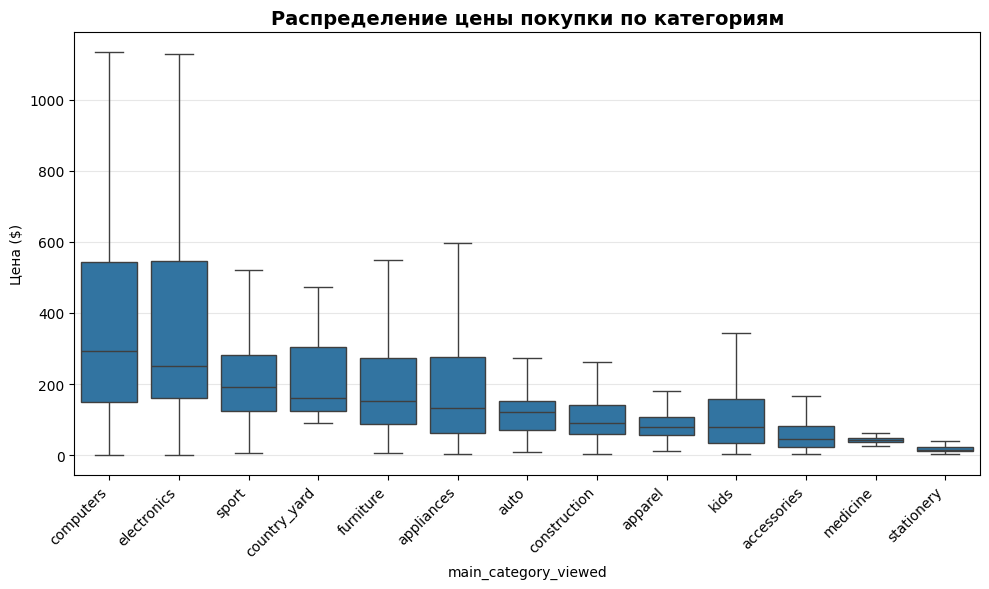

In [39]:
purchases_df = df[df['made_purchase'] == 1].copy()

# Сортировка по медиане
median_prices = purchases_df.groupby('main_category_viewed')['avg_price'].median().sort_values(ascending=False)
sorted_categories = median_prices.index.tolist()

plt.figure(figsize=(10, 6))


sns.boxplot(data=purchases_df, x='main_category_viewed', y='avg_price',
            order=sorted_categories,
            showfliers=False)
plt.title('Распределение цены покупки по категориям',
          fontweight='bold', fontsize=14)
plt.ylabel('Цена ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Хи-квадрат — это стандартный тест для вопроса: «Зависит ли одна категория от другой?»

Агрегация по user_id. Один юзер = одно наблюдение. Исключены категории с минимальными выборками.

In [43]:
exclude_cats = ['medicine', 'stationery', 'country_yard']
df_clean = df[~df['main_category_viewed'].isin(exclude_cats)]

user_cat = df_clean.groupby(['user_id', 'main_category_viewed']).agg(
    made_purchase=('made_purchase', 'max')
).reset_index()

contingency = pd.crosstab(user_cat['main_category_viewed'], user_cat['made_purchase'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Категорий после фильтра: {len(contingency)}")
print(f"Chi² = {chi2:.2f}, p = {p:.6f}")
print(f"Ячеек с expected < 5: {(expected < 5).sum()}")
print("Категория влияет на покупку" if p < 0.05 else "Связи нет")

# Cramér's V
n = user_cat.shape[0]
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Cramér's V = {cramers_v:.3f}")


Категорий после фильтра: 10
Chi² = 18963.61, p = 0.000000
Ячеек с expected < 5: 0
Категория влияет на покупку
Cramér's V = 0.107


Связь слабая: категория объясняет ~1% вариации в покупках

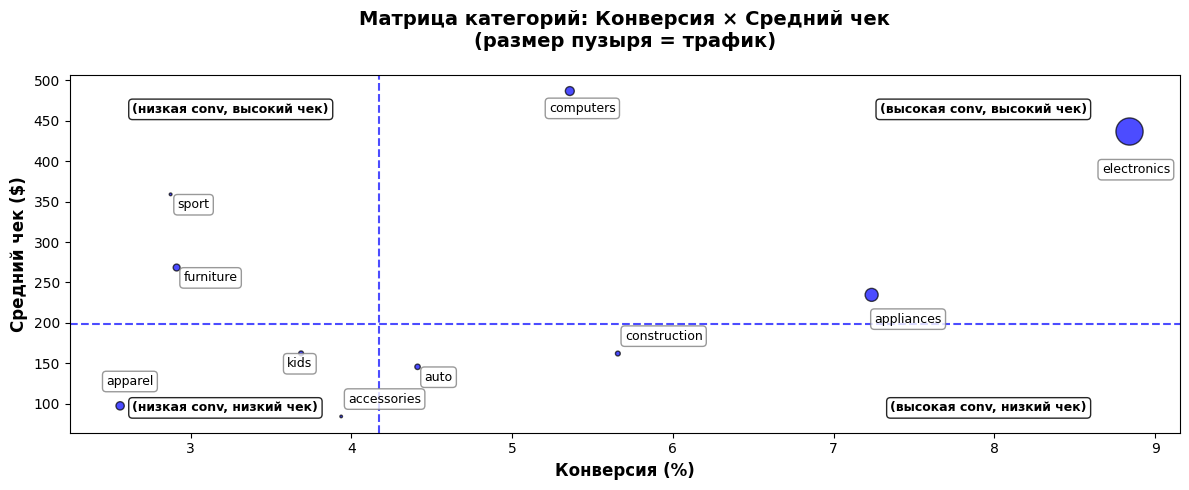

In [60]:
# Метрики по категориям
category_metrics = df_clean.groupby('main_category_viewed').agg(
    sessions=('user_session', 'nunique'),
    purchases=('made_purchase', 'sum'),
    avg_price=('avg_price', 'mean')
).reset_index()

# Конверсия в %
category_metrics['conversion'] = category_metrics['purchases'] / category_metrics['sessions'] * 100

# Матрица: Конверсия × Средний чек
fig, ax = plt.subplots(figsize=(12, 5))

# Scatter plot
scatter = ax.scatter(
    category_metrics['conversion'],
    category_metrics['avg_price'],
    s=category_metrics['sessions'] / 5000,
    alpha=0.7,
    c='blue',
    edgecolors='black',
    linewidth=1
)

# Подписи категорий
offsets = {
    'electronics': (-20, -30),
    'appliances': (2, -20),
    'computers': (-15, -15),
    'furniture': (5, -10),
    'apparel': (-10, 15),
    'auto': (5, -10),
    'construction': (5, 10),
    'kids': (-10, -10),
    'accessories': (5, 10),
    'sport': (5, -10)
}

for _, row in category_metrics.iterrows():
    cat = row['main_category_viewed']
    offset = offsets.get(cat, (5, 5))
    ax.annotate(
        cat,
        (row['conversion'], row['avg_price']),
        xytext=offset,
        textcoords='offset points',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )

# Линии квадрантов
med_conv = category_metrics['conversion'].median()
med_price = category_metrics['avg_price'].median()

ax.axvline(med_conv, color='blue', linestyle='--', alpha=0.7, linewidth=1.5)
ax.axhline(med_price, color='blue', linestyle='--', alpha=0.7, linewidth=1.5)

# Подписи квадрантов
x_min, x_max = category_metrics['conversion'].min(), category_metrics['conversion'].max()
y_min, y_max = category_metrics['avg_price'].min(), category_metrics['avg_price'].max()

ax.text(x_max * 0.97, y_max * 0.97, '(высокая conv, высокий чек)',
        ha='right', va='top', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.text(x_min * 1.03, y_max * 0.97, '(низкая conv, высокий чек)',
        ha='left', va='top', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.text(x_max * 0.97, y_min * 1.03, '(высокая conv, низкий чек)',
        ha='right', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.text(x_min * 1.03, y_min * 1.03, '(низкая conv, низкий чек)',
        ha='left', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

# Оформление
ax.set_xlabel('Конверсия (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Средний чек ($)', fontsize=12, fontweight='bold')
ax.set_title('Матрица категорий: Конверсия × Средний чек\n(размер пузыря = трафик)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()